In [96]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import CHIP
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

In [97]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=10)
chip.add_compiler("../code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 55294
正在编译文件:  ../code/read_point3.txt
正在编译文件:  ../code/read_point3_col.txt
正在编译文件:  ../code/row_read_point3.txt
正在编译文件:  ../code/set_reset.txt
正在编译文件:  ../code/write_verify.txt
正在编译文件:  ../code/汇编测试代码.txt
正在编译文件:  ../code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../code/读单点测试.txt


# 1.要写的权重

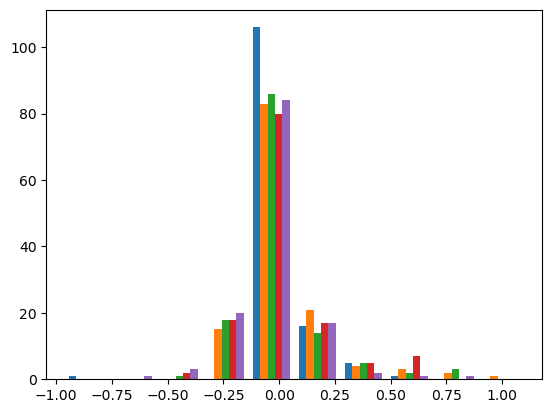

(129, 5)
1.0999255656084836 -0.9637450000000191


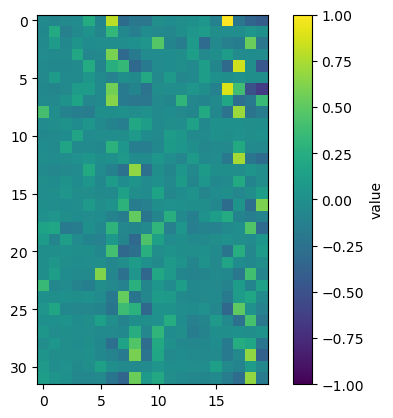

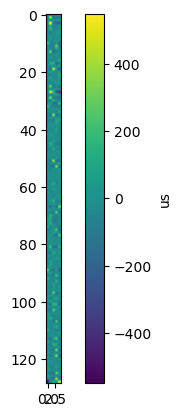

In [98]:
dl = DataLoader()
data = dl.load_mat("../data/svm/multi_svm_params.mat")["Wb"].T
plt.hist(data)
plt.show()
print(data.shape)
print(np.max(data),np.min(data))

cond_min,cond_max,cond_reference = 0,1100,550
cond_range = cond_max-cond_reference
weight_min,weight_max = -1,1
target_cond = data/weight_max*cond_range
plot_cond(data[:128,:].reshape(32,20),vmin=weight_min,vmax=weight_max,label="value")
plot_cond(target_cond,vmin=-cond_range,vmax=cond_range)

In [99]:
tg_map = np.array([1.5,1.55,1.6,1.65,1.7,1.75,1.8])
cond_map = np.array([350,390,450,490,550,590,650])
slope,intercept = np.polyfit(cond_map,tg_map, 1)

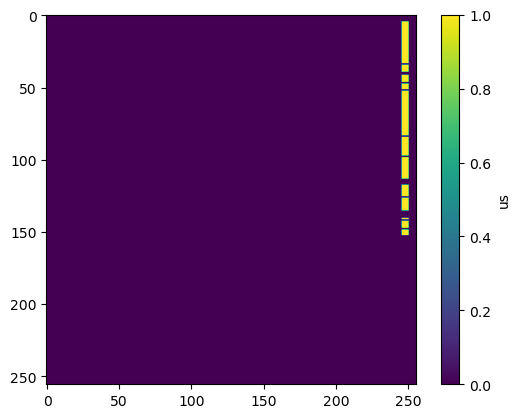

In [100]:
svm_weight_pos = np.load("../data/svm/svm_weight_pos.npz")
good_device = [np.array(svm_weight_pos["row"]),np.array(svm_weight_pos["col"])]
r_out = np.load("../data/chip_1_4_col_r_out.npy")
r_w = np.load("../data/chip_1_4_col_r_wire.npy")

# print(len(good_device[0]))
need_read = np.zeros((256,256),dtype=bool)
pos = np.ix_(good_device[0], good_device[1])
need_read[pos] = True
plot_cond(need_read,vmax=1)

In [101]:

# r_mean = np.mean(r_w)
# print(r_mean)
# for i,v in enumerate(svm_weight_pos["row"]):
#     for j,k in enumerate(svm_weight_pos["col"]):
#         r = 1/(target_cond[i,j]+cond_reference)*1e6 - r_out[k]
#         if v%2==0:
#             r -= ()
#         if k%2==0:
#             r -= (255-k)*r_w[k]
#         else:
#             r -= k*r_w[k]

        
#         target_cond[i,j] = 
#         # print(i,v)

# 2.写权重

In [ ]:
chip.ps.receive_packet(4096)

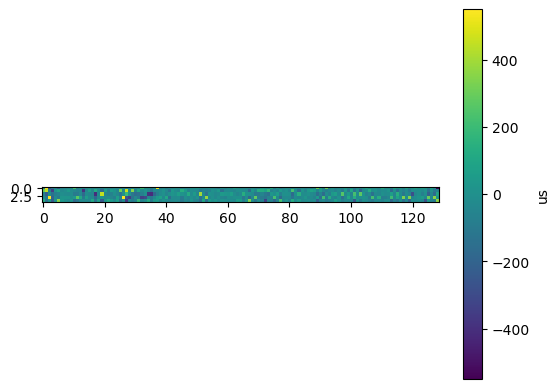

0 reset: 8 set 65


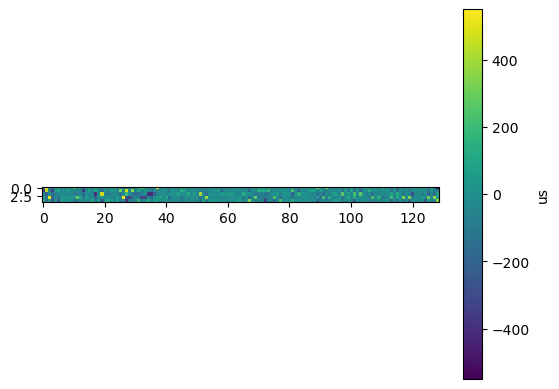

1 reset: 6 set 62


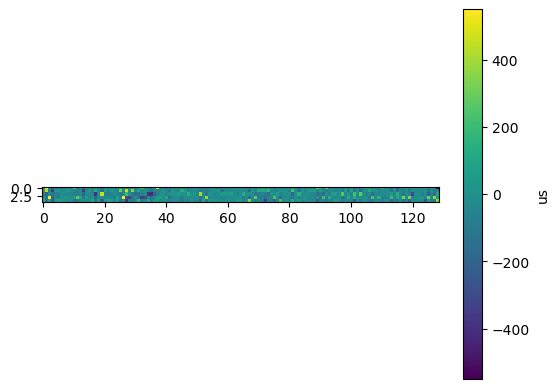

2 reset: 7 set 68


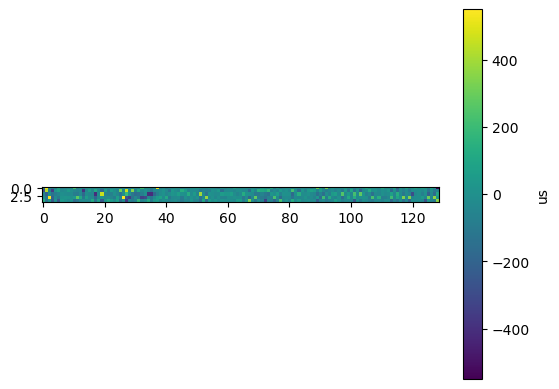

3 reset: 6 set 70


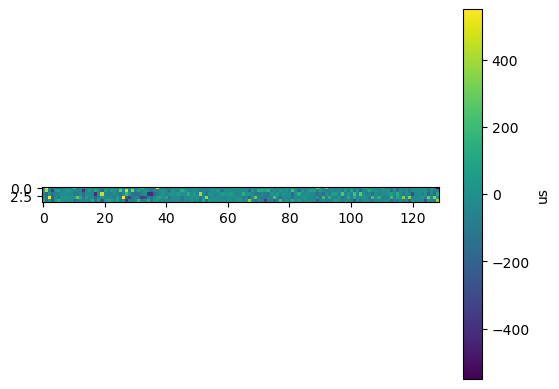

4 reset: 7 set 62


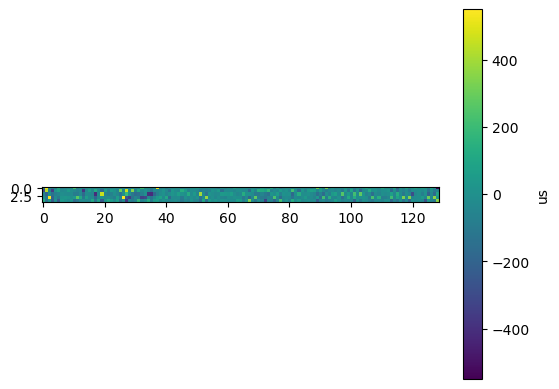

5 reset: 6 set 66


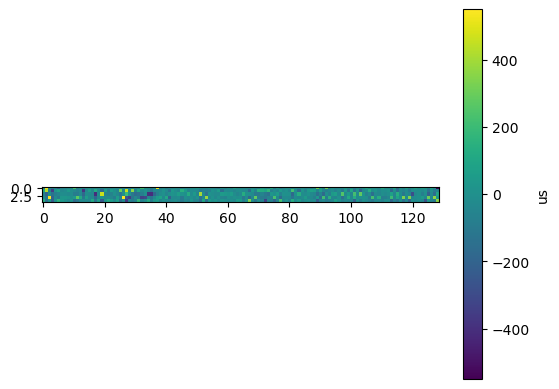

6 reset: 7 set 62


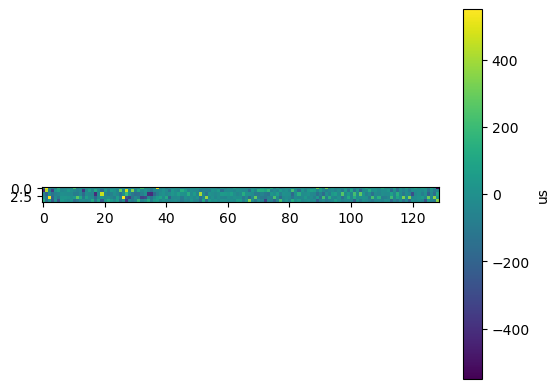

7 reset: 6 set 61


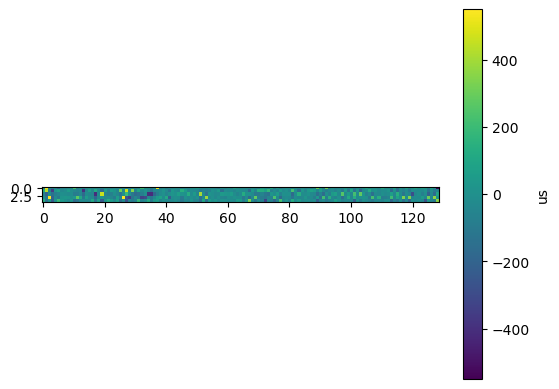

8 reset: 8 set 66


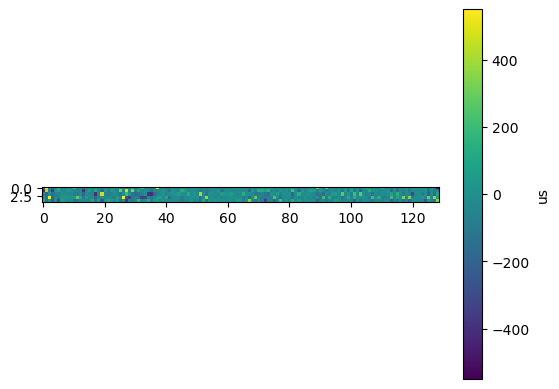

9 reset: 6 set 63


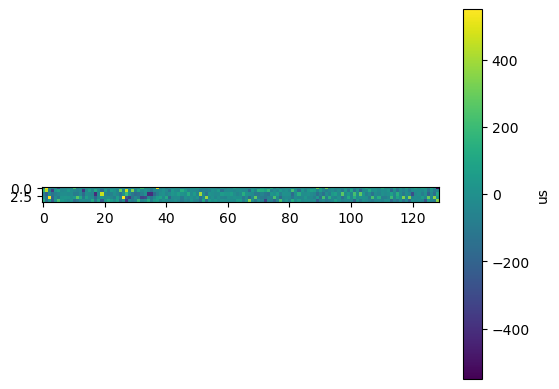

10 reset: 7 set 55


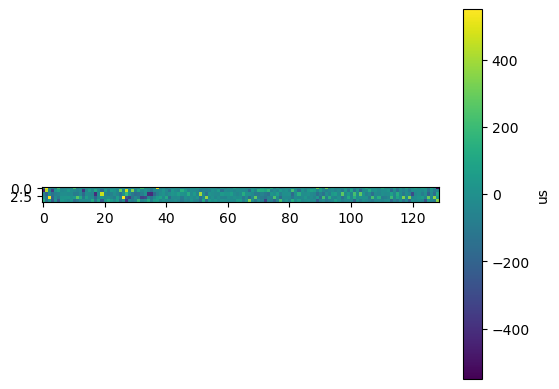

11 reset: 6 set 63


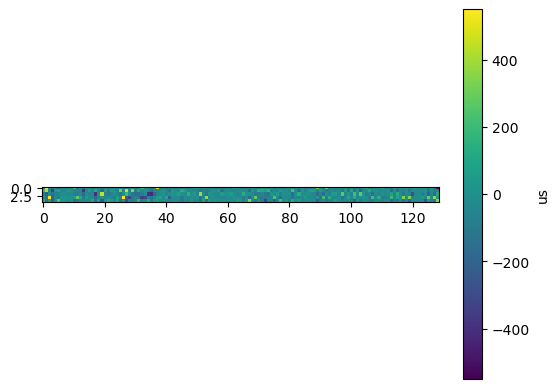

12 reset: 8 set 60


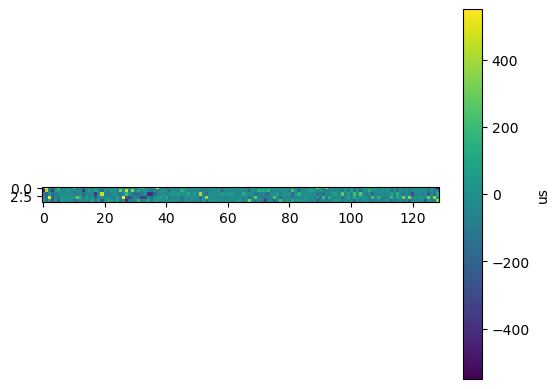

13 reset: 6 set 58


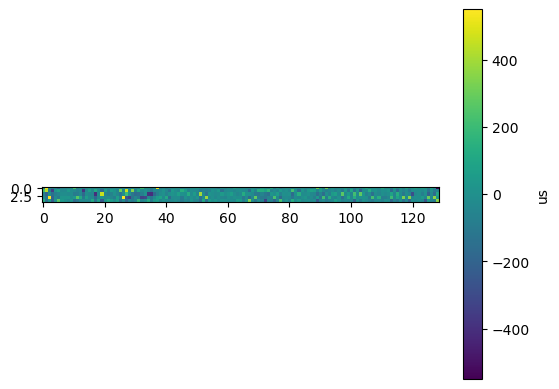

14 reset: 8 set 55


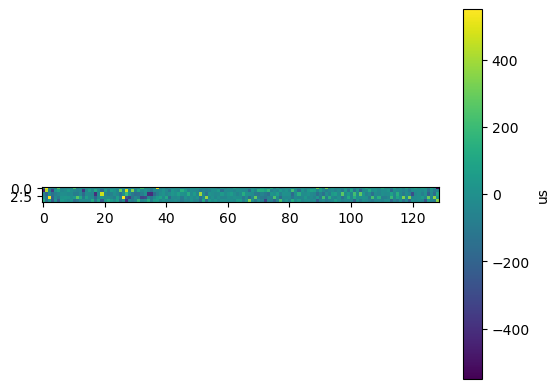

15 reset: 7 set 58


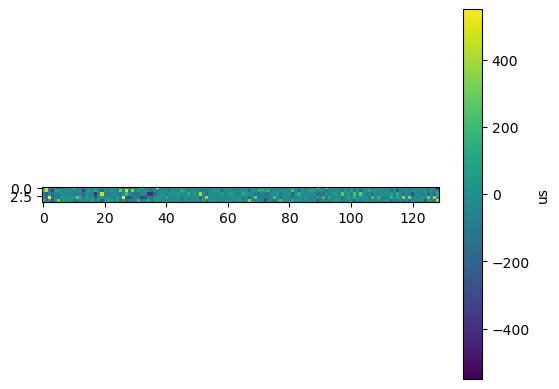

16 reset: 8 set 53


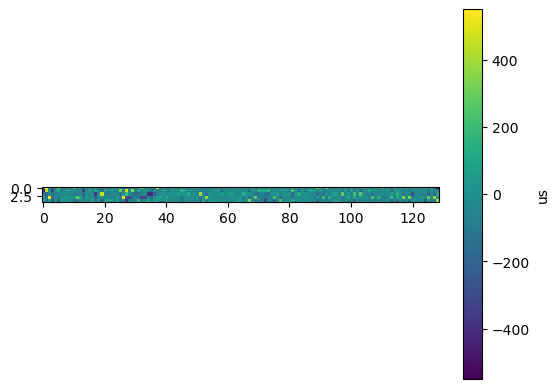

17 reset: 7 set 51


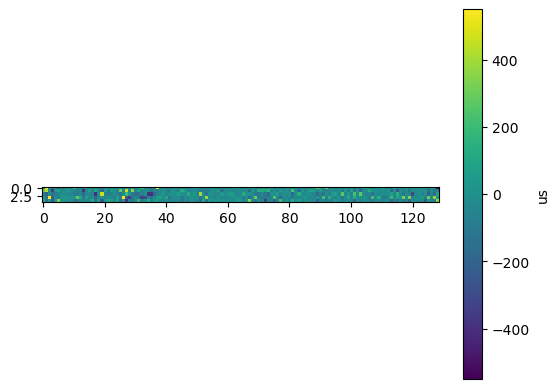

18 reset: 7 set 52


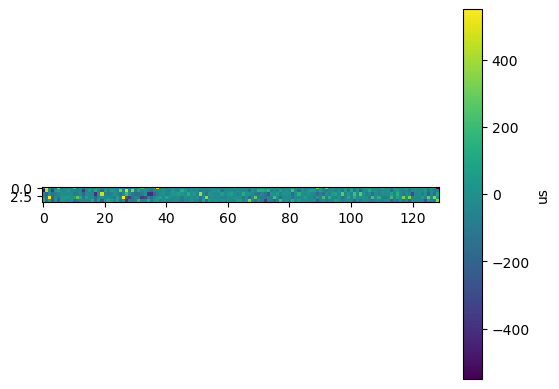

19 reset: 7 set 51


In [102]:
threshold = 30

set_v,reset_v = 1.5,1
reset_pulse_width,set_pulse_width = 100e-6,100e-6

need_read = np.zeros((256,256),dtype=bool)
need_read[pos] = True

target = np.ones((256,256))
target[pos] = target_cond + cond_reference

tg_v = target*slope+intercept-0.5


for i in range(20):
    voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
    plot_cond((cond[pos]-cond_reference).T,vmin=-cond_range,vmax=cond_range)

    condition_reset = (cond > (target+threshold)) & need_read
    condition_set = (cond < (target-threshold)) & need_read
    print(i,"reset:",np.sum(condition_reset),"set",np.sum(condition_set))

    if i>0:
        # set_v = set_v+0.05
        # if i<5:
        #     tg_v[condition_reset] -= 0.04
        #     tg_v[condition_set] += 0.04
        # elif i<10:
        #     tg_v[condition_reset] -= 0.02
        #     tg_v[condition_set] += 0.02
        # else:
            tg_v[condition_reset] -= 0.04
            tg_v[condition_set] += 0.02

    tg_v.clip(0,3,out=tg_v)

    chip.write_point2(crossbar=condition_reset,write_voltage=reset_v,tg=5,pulse_width=reset_pulse_width,set_device=False)
    chip.write_point2(crossbar=condition_reset,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)
    # # chip.ps.set_time_out(100)
    chip.write_point2(crossbar=condition_set,write_voltage=set_v,tg=tg_v,pulse_width=set_pulse_width,set_device=True)


# 3.测试读出来的权重推理效果

-0.9907889644847748


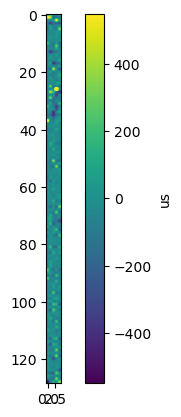

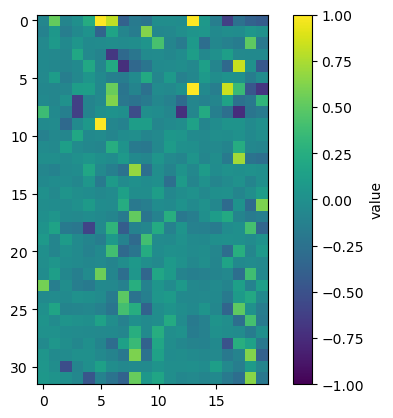

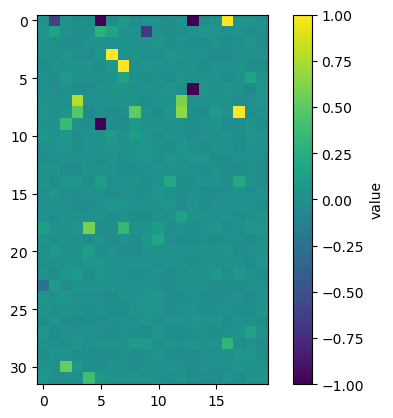

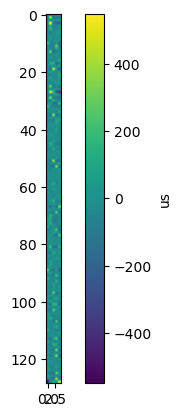

In [103]:
need_read = np.zeros((256,256),dtype=bool)
need_read[pos] = True
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[pos]
np.save("../data/svm/cond_sub_base_20250411.npy",cond)
cond = cond -cond_reference

W = cond/cond_range*weight_max

# W.clip(max=0.12,out=W)
print(np.min(W))
plot_cond(cond,vmin=-cond_range,vmax=cond_range)
plot_cond(W[:128,:].reshape(32,20),vmin=-1,vmax=1,label="value")
plot_cond(data[:128,:].reshape(32,20)-W[:128,:].reshape(32,20),vmin=weight_min,vmax=weight_max,label="value")
plot_cond(target_cond,vmin=-cond_range,vmax=cond_range,)

In [104]:
import scipy.io as sio
import numpy as np

mat_contents = sio.loadmat('../data/svm/train3.mat')  # 替换为实际文件路径
data = mat_contents['train_3']  # 根据实际文件中的变量名调整

# 数据中前128列为特征，最后1列为标签（原始标签取值为 1~5）
X = data[:, :128]  # 特征矩阵，尺寸为 (N, d) 其中 d=128
y = data[:, 128].flatten()  # 标签向量，尺寸为 (N, )
# 为方便运算，将标签调整到 0~K-1 （K=5）
y = y - 1


ones_column = np.ones((15000, 1),dtype=int)

# 使用np.concatenate函数将这一列添加到原始矩阵的最后
X_NEW = np.concatenate((X, ones_column), axis=1)

In [105]:
sum0 = np.sum(X_NEW==0)
sum1 = np.sum(X_NEW==1)
sum2 = np.sum(X_NEW==2)
print(sum0+sum1+sum2)

1935000


In [106]:
print(y)
# for i in y[9000:12000]:
#     print(i)

# X尺寸为15000*128
print(X_NEW.shape)
tmp=np.sum(X_NEW,axis=1)
print(np.max(tmp))
# for i in np.sum(X,axis=1):
#     print(i)
# plt.hist(X_NEW)
# plt.show()

print(W.shape)
W2 = dl.load_mat("../data/svm/multi_svm_params.mat")["Wb"].T
print(W2.shape)

[0 0 0 ... 4 4 4]
(15000, 129)
53
(129, 5)
(129, 5)


In [108]:
scores_all = np.dot(X_NEW, W2) 
# 整个训练集的得分，尺寸 (num_samples, K)
y_pred = np.argmax(scores_all, axis=1)  # 预测的类别（0~K-1）
acc = np.mean(y_pred == y)

# 输出当前迭代的损失和预测准确率
print(f"Accuracy = {acc * 100:.2f}%")

scores_all = np.dot(X_NEW, W)
# 整个训练集的得分，尺寸 (num_samples, K)
y_pred = np.argmax(scores_all, axis=1)  # 预测的类别（0~K-1）
acc = np.mean(y_pred == y)

# 输出当前迭代的损失和预测准确率
print(f"Accuracy = {acc * 100:.2f}%")



Accuracy = 84.71%
Accuracy = 78.30%


# 4.片上推理测试

In [ ]:
svm_weight_pos = np.load("../data/svm/svm_weight_pos.npz")
good_device = [np.array(svm_weight_pos["row"]),np.array(svm_weight_pos["col"])]
r_out = np.load("../data/chip_1_4_col_r_out.npy")
r_w = np.load("../data/chip_1_4_col_r_wire.npy")


# 从行给信号
row_index = good_device[0][:50]
col_index = good_device[1]
row_nums = len(row_index)
print(row_nums)

min_row,max_row = np.min(row_index),np.max(row_index)
print(min_row,max_row)
row_rw = np.array([(256-max_row)*r_w[i] if i%2==0 else (min_row-20)*r_w[i] for i in col_index])

gain = 1 if row_nums<=10 else 3
from_row = True
# -------------------------------------
voltage_base = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                            read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0,compute=True
                                        ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                        )
voltage = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                    read_voltage=0.1,tg=5,gain=gain, from_row=from_row,out_type=0,compute=True
                                    ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                    )
parallel_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w[col_index]*(row_nums**0.87)
print(parallel_r.shape)
cond0 = 1/parallel_r*1e6
# 单位A
parallel_i = 1/parallel_r - cond_reference*1e-6*row_nums
parallel_value = parallel_i/(cond_range*1e-6)*weight_max
# -------------------------------------
need_read = np.zeros((256,256),dtype=bool)
weight_pos = np.ix_(row_index, col_index)
need_read[weight_pos] = True

voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
not_parallel_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w[col_index]*(row_nums**0.87)
print(not_parallel_r.shape)
# 单位A
cond1 = 1/not_parallel_r*1e6
not_parallel_i = 1/not_parallel_r - cond_reference*1e-6*row_nums
not_parallel_value = not_parallel_i/(cond_range*1e-6)*weight_max
# -------------------------------------
need_read = np.zeros((256,256),dtype=bool)
weight_pos = np.ix_(row_index, col_index)
need_read[weight_pos] = True
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]
cond = np.sum(cond,axis=0)
# 单位A
real_i =cond*1e-6 - cond_reference*1e-6*row_nums
print(real_i.shape)
print(cond_reference*row_nums)
real_value = real_i/(cond_range*1e-6)*weight_max

for i in range(5):
    # print(col_index[i],cond[i],cond[i],cond0[0,i],cond[i]-cond1[0,i])
    print(col_index[i],cond[i],cond0[0,i],cond1[0,i])
    # print(col_index[i],real_value[i]-not_parallel_value[0,i],real_value[i])
    # print((256-max_row)*r_w[i] if col_index[i]%2==0 else min_row*r_w[i])
    # print(real_i[i],parallel_i[0,i],not_parallel_i[0,i])
    # print(real_value[i],parallel_value[0,i],not_parallel_value[0,i])
    # print(real_value[i]-parallel_value[0,i],real_value[i]-not_parallel_value[0,i])
    # print()


In [ ]:
change256 = np.zeros((129,3))
for i in range(129):
    print(i,end=" ")
    col = good_device[1][1]

    need_read = np.zeros((256,256),dtype=bool)
    weight_pos = np.ix_(good_device[0][:i],[col])
    need_read[weight_pos] = True

    min_row,max_row = np.min(row_index),np.max(row_index)
    wire_r = (255-max_row)*r_w[i] if col%2==0 else (min_row)*r_w[i]
    row_nums = len(row_index)


    voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
    voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
    real_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[weight_pos] #- wire_r# - r_out[col]*1e-3 
    real_cond = np.sum(1/real_r*1e3)


    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)
    real_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[0,col]*1e3 - r_out[col] - wire_r - r_w[col]*(i**0.785)
    cond = 1/real_r*1e6


    voltage_base = chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=3,from_row=True,out_type=0)
    voltage = chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=0)
    real_r = chip.voltage_to_resistance(voltage = voltage-voltage_base)[0,col]*1e3 - r_out[col] - wire_r
    cond2 = 1/real_r*1e6


    change256[i,0]=real_cond
    change256[i,1]=cond
    change256[i,2]=cond2

In [ ]:
print(good_device[1])
plt.plot(change256[:,0],label = "real")
plt.plot(change256[:,1],label = "Compensation")
plt.plot(change256[:,2],label ="No Compensation")
ans = change256[:,0]-change256[:,1]
print(ans[:50])
# plt.title("")
plt.ylabel("uS")
plt.xlabel("row nums")
plt.legend()
plt.show()

In [ ]:
print(np.diff(good_device[0]))
print(good_device[0],good_device[1])

In [109]:

r_out = np.load("../data/chip_1_4_col_r_out.npy")
r_w = np.load("../data/chip_1_4_col_r_wire.npy")
need_read = np.zeros((256,256),dtype=bool)
def forward_unsigned_from_row(row_index,col_index,forward_type=1,value = 0.875):
    """
        从行给信号进行推理
    """
    col_nums,row_nums = len(col_index),len(row_index)
    from_row = True
    if col_nums <= 0:
        return np.zeros((len(row_index),1))
    
    min_row,max_row = np.min(row_index),np.max(row_index)
    row_rw = np.array([(256-max_row)*r_w[i] if i%2==0 else (min_row)*r_w[i] for i in col_index])
    gain = 1 if row_nums<=10 else 3
    if forward_type==1:
        # -------------------------------------
        # voltage_base = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
        #                                             read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0,compute=True
        #                                         # ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
        #                                         # ,tia_split=[0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,]
        #                                         # ,tia_split=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,]
        #                                         )
        voltage = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index],
                                            read_voltage=0.1,tg=5,gain=gain, from_row=from_row,out_type=0,compute=True
                                            # ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                            # ,tia_split=[0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,]
                                            # ,tia_split=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,]
                                            )
        parallel_r = chip.voltage_to_resistance(voltage = voltage)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w[col_index]*(row_nums**value)
        # 单位A
        parallel_i = 1/parallel_r - cond_reference*1e-6*row_nums
        parallel_value = parallel_i/(cond_range*1e-6)*weight_max
        return parallel_value.flatten()
    elif forward_type==2:
        need_read[:]=False
        weight_pos = np.ix_(row_index, col_index)
        need_read[weight_pos] = True

        # voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=from_row,out_type=0)
        voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=from_row,out_type=0)
        not_parallel_r = chip.voltage_to_resistance(voltage = voltage)[:,col_index]*1e3 - r_out[col_index] - row_rw - r_w[col_index]*(row_nums**value)
        # 单位A
        not_parallel_i = 1/not_parallel_r - cond_reference*1e-6*row_nums
        not_parallel_value = not_parallel_i/(cond_range*1e-6)*weight_max
        return not_parallel_value.flatten()
    elif forward_type==3:
        # need_read = np.zeros((256,256),dtype=bool)
        # weight_pos = np.ix_(row_index, col_index)
        # need_read[weight_pos] = True
        # voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=from_row,out_type=0)
        # voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=from_row,out_type=0)
        # cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]-cond_reference
        # cond =np.sum(cond,axis=0)

        # return (cond/cond_range*weight_max).flatten()
        # need_read = np.zeros((256,256),dtype=bool)
        need_read[:]=False
        weight_pos = np.ix_(row_index, col_index)
        need_read[weight_pos] = True
        voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=from_row,out_type=0)
        voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=from_row,out_type=0)
        cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]

        # 单位A
        real_i =np.sum(cond,axis=0) - cond_reference*row_nums
        real_value = real_i/(cond_range)*weight_max
        return real_value.flatten()
    

In [110]:
# 两个100个元素的列表
svm_weight_pos = np.load("../data/svm/svm_weight_pos.npz")
good_device = [np.array(svm_weight_pos["row"]),np.array(svm_weight_pos["col"])]

def forward_from_row_svm(x:np.ndarray,interval = 60,forward_type = 3,value=0.875):
    """
        x只有3个值,0,1,2
        单列输出用0.785
    """
    col_index = good_device[1]
    y = np.zeros((len(col_index)))
    x = x.flatten()

    
    row_index = good_device[0][np.where(x > 1.5)]
    row_nums = len(row_index)
    steps = math.ceil(row_nums/interval)
    if row_nums>0:
        for i in range(steps):
            y += forward_unsigned_from_row(row_index[i*interval:min((i+1)*interval,row_nums)],col_index,forward_type=forward_type,value=value)
    

    row_index = good_device[0][np.where(x > 0.5)]
    row_nums = len(row_index)
    if row_nums>0:
        steps = math.ceil(row_nums/interval)
        for i in range(steps):
            y += forward_unsigned_from_row(row_index[i*interval:min((i+1)*interval,row_nums)],col_index,forward_type=forward_type,value=value)

    return y

In [117]:
select_num = 2000
rows_to_select = np.random.choice(X_NEW.shape[0], select_num, replace=False)
X_SELECT = X_NEW[rows_to_select, :]
Y_SELECT = y[rows_to_select]
print(X_SELECT.shape,Y_SELECT.shape)

(2000, 129) (2000,)


In [118]:
# scores_all = np.dot(X_NEW, W2) 
# # 整个训练集的得分，尺寸 (num_samples, K)
# y_pred = np.argmax(scores_all, axis=1)  # 预测的类别（0~K-1）
# acc = np.mean(y_pred == y)

# # 输出当前迭代的损失和预测准确率
# print(f"Accuracy = {acc * 100:.2f}%")






# scores_all = np.dot(X_SELECT, W)

scores_all = np.zeros((select_num,5))

for i in range(select_num):
    scores_all[i,:]=forward_from_row_svm(X_SELECT[i,:],interval=60,forward_type=2,value=0.875)

y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y_SELECT)
print(f"Accuracy = {acc * 100:.2f}%")

np.save("../data/svm/correct_data.npy",rows_to_select[y_pred == Y_SELECT])

Accuracy = 79.00%


In [121]:
rows_to_select=np.load("../data/svm/correct_data.npy")
print(rows_to_select.shape)
select_num = len(rows_to_select)
X_SELECT = X_NEW[rows_to_select, :]
Y_SELECT = y[rows_to_select]

print(select_num)
scores_all = np.zeros((select_num,5))

for i in range(select_num):
    scores_all[i,:]=forward_from_row_svm(X_SELECT[i,:],interval=60,forward_type=2,value=0.875)

y_pred = np.argmax(scores_all, axis=1)
acc = np.mean(y_pred == Y_SELECT)
print(f"Accuracy = {acc * 100:.2f}%")

np.save("../data/svm/correct_data.npy",rows_to_select[y_pred == Y_SELECT])

(1579,)
1579
Accuracy = 99.81%
